In [21]:
import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
# ---------------------------------------------------------
# 1. LOAD DATA & SETUP (Your code)
# ---------------------------------------------------------
# df = pd.read_csv('your_data.csv') # Uncomment for real run
# For this example, I'll simulate data that matches your variable names so the code runs immediately
np.random.seed(42)
df = pd.read_csv('data/NC_sample_imperv_rad_data.csv')  # Replace with your actual data source

#sample 5000 rows for faster processing in this example
df = df.sample(5000, random_state=42).reset_index(drop=True)

offset = 0.1
df['radiance_shifted'] = df['viirs_radiance'] + offset

# ---------------------------------------------------------
# 2. FIT THE MODEL (Your code)
# ---------------------------------------------------------
model = bmb.Model("radiance_shifted ~ mean_impervious", data=df, family="gamma", link="log")

# Using nutpie as requested (make sure nutpie is installed)
results = model.fit(draws=2000, tune=1000, chains=2, random_seed=42, inference_method='nutpie')

# ---------------------------------------------------------
# 3. PREPARE VISUALIZATION DATA
# ---------------------------------------------------------

# A. Generate the "Smooth Curve" and "Cone of Uncertainty"
# We need a continuous grid from 0 to 100 to draw the lines
grid_data = pd.DataFrame({"mean_impervious": np.linspace(0, 100, 200)})

# Predict distribution for the grid
# inplace=False prevents modifying the original results object, keeping it clean
pps_grid = model.predict(results, data=grid_data, kind="pps", inplace=False)

# Extract samples: Shape is (chains, draws, observations)
# We stack chains and draws to get a flat list of samples per observation
grid_samples = pps_grid.posterior_predictive["radiance_shifted"].stack(sample=("chain", "draw")).values

# Calculate Statistics (Median + 90% Interval)
# Note: We subtract 'offset' to convert back to real VIIRS units
y_median = np.median(grid_samples, axis=1) - offset
y_lower = np.percentile(grid_samples, 5, axis=1) - offset
y_upper = np.percentile(grid_samples, 95, axis=1) - offset

# B. Generate "Simulated Future Scenarios" (The Red Dots)
# These represent the "semi-random" nature of your future predictions
target_impervious_values = [20, 50, 80]
future_dots_x = []
future_dots_y = []

# We create a temporary dataframe for these specific targets
future_targets = pd.DataFrame({"mean_impervious": target_impervious_values})
pps_future = model.predict(results, data=future_targets, kind="pps", inplace=False)
future_samples = pps_future.posterior_predictive["radiance_shifted"].stack(sample=("chain", "draw")).values

# For each target (20, 50, 80), grab 30 random realizations to show the spread
for i, imp_val in enumerate(target_impervious_values):
    # Grab 30 random samples
    random_draws = np.random.choice(future_samples[i, :], size=30) - offset
    
    # Store Y values
    future_dots_y.extend(random_draws)
    
    # Store X values with random "jitter" so they don't stack perfectly on top of each other
    jitter = np.random.normal(0, 1.5, size=30) 
    future_dots_x.extend([imp_val] * 30 + jitter)

# ---------------------------------------------------------
# 4. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Layer 1: The Raw Data (Black dots)
# We plot a subset (e.g. 1000 points) to avoid overcrowding if dataset is huge
sns.scatterplot(data=df, x='mean_impervious', y='viirs_radiance', alpha=0.5)

# Layer 2: The Model Distribution (Blue Line + Cone)
plt.plot(grid_data['mean_impervious'], y_median, color='#005b96', linewidth=2, label='Predicted Median Trend')
plt.fill_between(grid_data['mean_impervious'], y_lower, y_upper, color='#005b96', alpha=0.15, label='90% Prediction Interval')

# Layer 3: The Simulated Future Samples (Red dots)
plt.scatter(future_dots_x, future_dots_y, color='#d62728', edgecolor='white', 
            s=60, alpha=0.9, zorder=5, label='Simulated "Future" Forecasts')

# Formatting
plt.xlabel('Imperviousness (%)', fontsize=12)
plt.ylabel('VIIRS Night Light Radiance', fontsize=12)
plt.title('Bayesian Gamma Regression: Probabilistic Forecasting', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

# Set Constraints
plt.xlim(-2, 102)
# Set Y limit to a reasonable max (e.g., 98th percentile of your data to ignore extreme outliers)
ymax = np.percentile(df['viirs_radiance'], 99) * 1.2
plt.ylim(bottom=0, top=400)

plt.tight_layout()
plt.show()

/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/nutpie/compile_pymc.py:808: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', True, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  return inner(x)
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/nutpie/compile_pymc.py:808: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'F', True, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  return inner(x)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,447
,3000,0,0.08,31


/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/arviz/data/base.py:181: UserWarning: In variable bs(mean_impervious, df=5), there are more dims (2) given than exist (1). Passed array should have shape (chain,draw, *shape)
  warnings.warn(


KeyError: ' df=5)_dim'

Initializing NUTS using jitter+adapt_diag...


Starting sampling...


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, poly(mean_impervious, 2)]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


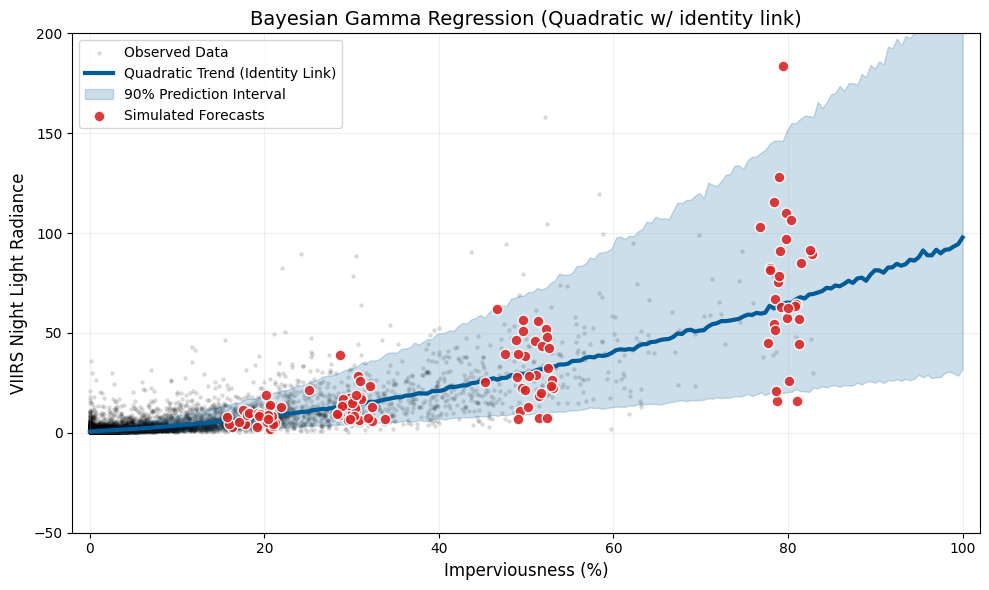

In [13]:
import pandas as pd
import numpy as np
import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
df = pd.read_csv('data/NC_sample_imperv_rad_data.csv')
df = df.sample(20000, random_state=42).reset_index(drop=True)

# Offset (Crucial for Gamma)
offset = 0.1
df['radiance_shifted'] = df['viirs_radiance'] + offset

# ---------------------------------------------------------
# 2. FIT THE MODEL (Quadratic + Identity Link)
# ---------------------------------------------------------
# poly(mean_impervious, 2) = Fits a parabola (y = ax^2 + bx + c)
# link="identity" = Forces the curve to be additive, not exponential.
model = bmb.Model("radiance_shifted ~ poly(mean_impervious, 2)", 
                  data=df, 
                  family="gamma", 
                  link="identity") 

print("Starting sampling...")
# We use standard PyMC sampler for stability with identity links
results = model.fit(draws=2000, tune=1000, chains=2, random_seed=42, mode = 'NUMBA', cores = 10)

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------

# A. Smooth Grid Prediction
grid_data = pd.DataFrame({"mean_impervious": np.linspace(0, 100, 200)})
pps_grid = model.predict(results, data=grid_data, kind="pps", inplace=False)
grid_samples = pps_grid.posterior_predictive["radiance_shifted"].stack(sample=("chain", "draw")).values

# Calculate Stats
y_median = np.median(grid_samples, axis=1) - offset
y_lower = np.percentile(grid_samples, 5, axis=1) - offset
y_upper = np.percentile(grid_samples, 95, axis=1) - offset

# B. Future Dots (Simulated Scenarios)
target_imps = [20, 30, 50, 80]
future_targets = pd.DataFrame({"mean_impervious": target_imps})
pps_future = model.predict(results, data=future_targets, kind="pps", inplace=False)
future_samples = pps_future.posterior_predictive["radiance_shifted"].stack(sample=("chain", "draw")).values

future_x = []
future_y = []
for i, imp in enumerate(target_imps):
    # Grab 30 random draws
    draws = np.random.choice(future_samples[i, :], size=30) - offset
    future_y.extend(draws)
    # Jitter X
    future_x.extend([imp] * 30 + np.random.normal(0, 1.5, size=30))

# ---------------------------------------------------------
# 4. PLOT
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Observed Data
sns.scatterplot(data=df, x='mean_impervious', y='viirs_radiance', 
                color='black', alpha=0.15, s=10, linewidth=0, label='Observed Data')

# Model Trend
plt.plot(grid_data['mean_impervious'], y_median, color='#005b96', linewidth=3, label='Quadratic Trend (Identity Link)')
plt.fill_between(grid_data['mean_impervious'], y_lower, y_upper, color='#005b96', alpha=0.2, label='90% Prediction Interval')

# Forecasts
plt.scatter(future_x, future_y, color='#d62728', edgecolor='white', 
            s=60, alpha=0.9, zorder=5, label='Simulated Forecasts')

plt.xlabel('Imperviousness (%)', fontsize=12)
plt.ylabel('VIIRS Night Light Radiance', fontsize=12)
plt.title('Bayesian Gamma Regression (Quadratic w/ identity link)', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.xlim(-2, 102)

# Set Y limit to reasonable max to see the curve clearly
plt.ylim(bottom=-50, top=200)

plt.tight_layout()
plt.show()

Size of results object: 48 MB


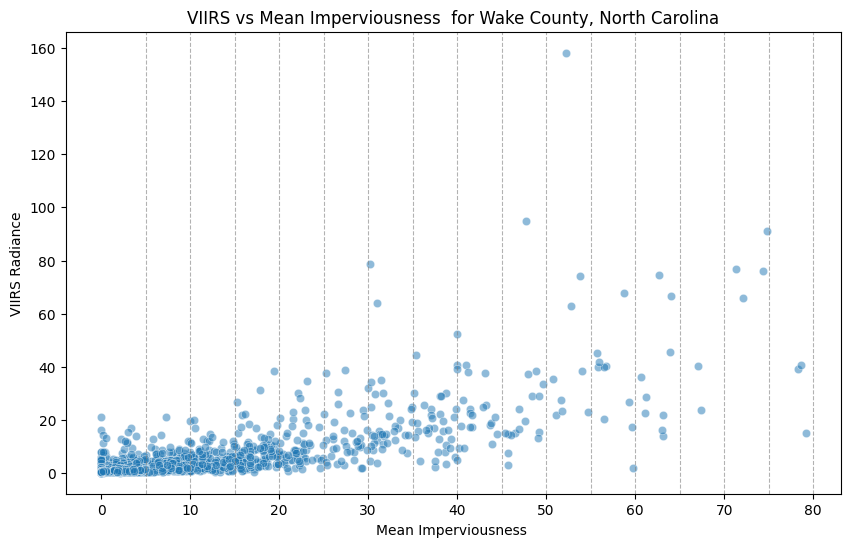

In [17]:
#Plot mean vs viirs
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mean_impervious', y='viirs_radiance', alpha=0.5)
plt.title(f'VIIRS vs Mean Imperviousness  for Wake County, North Carolina')
plt.ylabel('VIIRS Radiance')
plt.xlabel(f'Mean Imperviousness ')
plt.grid(False)

# Add vertical lines at 5, 10, ..., 95 to separate 0-5,5-10,...,95-100 bins
ax = plt.gca()
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
for b in range(5, 100, 5):
    if xmin <= b <= xmax:
        ax.vlines(b, ymin=ymin, ymax=ymax, color='gray', alpha=0.6, linewidth=0.8, linestyle='--')

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:       radiance_shifted   No. Observations:                 5000
Model:                            GLM   Df Residuals:                     4997
Model Family:                   Gamma   Df Model:                            2
Link Function:               Identity   Scale:                         0.81479
Method:                          IRLS   Log-Likelihood:                -6150.8
Date:                Thu, 04 Dec 2025   Deviance:                       1575.2
Time:                        15:37:39   Pearson chi2:                 4.07e+03
No. Iterations:                    12   Pseudo R-squ. (CS):             0.7407
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


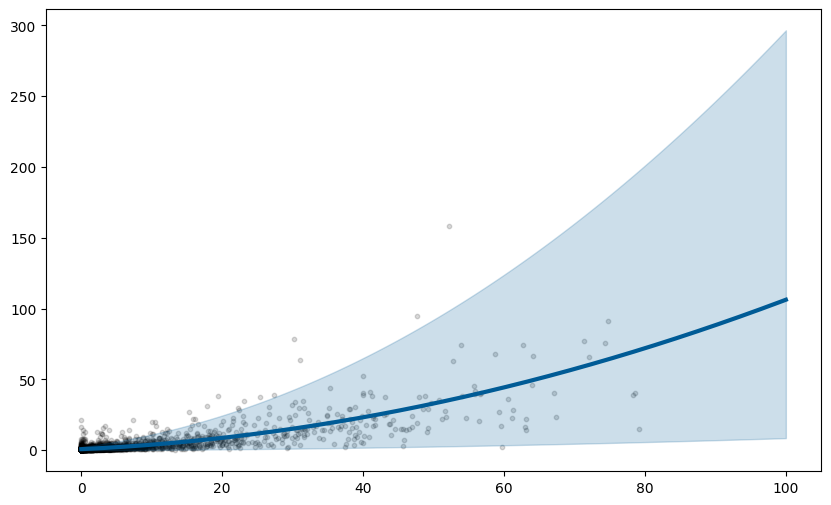

In [40]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import gamma
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('data/NC_sample_imperv_rad_data.csv') # Replace with your file
df = df.sample(5000, random_state=42).reset_index(drop=True)

# Offset (Crucial for Gamma)
offset = 0.1
df['radiance_shifted'] = df['viirs_radiance'] + offset

# ---------------------------------------------------------
# 2. FIT THE MODEL (Frequentist GLM)
# ---------------------------------------------------------
# formula: "radiance ~ x + x^2"
# link: Identity (Additive model, prevents exponential explosion)
freq_model = smf.glm(
    formula="radiance_shifted ~ mean_impervious + I(mean_impervious ** 2)", 
    data=df, 
    family=sm.families.Gamma(link=sm.families.links.Identity())
).fit()

# Extract parameters for manual simulation
# Statsmodels reports 'scale' which is the dispersion parameter (phi)
# Gamma Shape (alpha) = 1 / dispersion
dispersion = freq_model.scale 
shape_param = 1.0 / dispersion

print(freq_model.summary())

# ---------------------------------------------------------
# 3. PREPARE VISUALIZATION
# ---------------------------------------------------------

# A. Smooth Trend Line & Intervals
x_grid = np.linspace(0, 100, 200)
pred_df = pd.DataFrame({'mean_impervious': x_grid})

# Predict Mean (Mu)
pred_mu = freq_model.predict(pred_df)

# Calculate Prediction Intervals (Analytical)
# The variance of Gamma is (Mean^2 * dispersion).
# We use scipy.stats.gamma.ppf to find the 5th and 95th percentiles.
# Scipy parameter mapping: a=shape, scale=mu*dispersion
y_lower = gamma.ppf(0.05, a=shape_param, scale=pred_mu * dispersion) - offset
y_upper = gamma.ppf(0.95, a=shape_param, scale=pred_mu * dispersion) - offset
y_mean = pred_mu - offset

# B. Simulated Future Forecasts (Red Dots)
target_imps = [20, 50, 80, 95]
future_x = []
future_y = []

for imp in target_imps:
    # 1. Predict Mean for this specific x
    mu_val = freq_model.predict(pd.DataFrame({'mean_impervious': [imp]})).iloc[0]
    
    # 2. Sample from Gamma distribution to simulate noise
    sim_values = gamma.rvs(a=shape_param, scale=mu_val * dispersion, size=30)
    
    future_y.extend(sim_values - offset)
    # Add jitter to x
    future_x.extend([imp] * 30 + np.random.normal(0, 1.5, size=30))

# ---------------------------------------------------------
# 4. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Observed Data
plt.scatter(df['mean_impervious'], df['viirs_radiance'], 
            color='black', alpha=0.15, s=10, label='Observed Data')

#add lower and upper bounds
plt.plot(x_grid, y_mean, color='#005b96', linewidth=3, label='Frequentist GLM Trend')
plt.fill_between(x_grid, y_lower, y_upper, color='#005b96', alpha=0.2, label='90% Prediction Interval') 

# Model Trend

In [1]:
model

NameError: name 'model' is not defined